In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
amounts = [120, 450, 870, 230, 1500, 340, 670, 90, 2100, 500, 780, 55]

def summarise(amounts, threshold):
    above = sorted([x for x in amounts if x > threshold], reverse=True)
    mean = sum(amounts) / len(amounts)
    return {
        'above_threshold': above,
        'mean': mean,
        'count_above': len(above)
    }

result = summarise(amounts, threshold=500)
print(result)

{'above_threshold': [2100, 1500, 870, 780, 670], 'mean': 642.0833333333334, 'count_above': 5}


In [4]:
df_raw = pd.read_csv('transactions.csv')
arr = df_raw['amount'].to_numpy()

print(f"Mean:   {np.mean(arr):.2f}")
print(f"Median: {np.median(arr):.2f}")
print(f"Std:    {np.std(arr):.2f}")
print(f"10th percentile: {np.percentile(arr, 10):.2f}")
print(f"90th percentile: {np.percentile(arr, 90):.2f}")

mean, std = np.mean(arr), np.std(arr)
outlier_mask = np.abs(arr - mean) > 2 * std
print(f"\nOutlier count: {outlier_mask.sum()}")

amounts_norm = (arr - arr.min()) / (arr.max() - arr.min())

counts, bin_edges = np.histogram(amounts_norm, bins=10)
print("\nHistogram (10 bins):")
for i in range(len(counts)):
    print(f"  [{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f}) -> {counts[i]}")

Mean:   1253.02
Median: 433.38
Std:    1989.76
10th percentile: 88.25
90th percentile: 4024.01

Outlier count: 353

Histogram (10 bins):
  [0.000, 0.100) -> 4020
  [0.100, 0.200) -> 479
  [0.200, 0.300) -> 191
  [0.300, 0.400) -> 187
  [0.400, 0.500) -> 141
  [0.500, 0.600) -> 81
  [0.600, 0.700) -> 47
  [0.700, 0.800) -> 18
  [0.800, 0.900) -> 8
  [0.900, 1.000) -> 4


In [5]:
df = pd.read_csv('transactions.csv')

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month

print("\nStatistical Summary (numeric):")
print(df.describe())

print(f"\nUnique cities ({df['city'].nunique()}): {df['city'].unique().tolist()}")
print(f"Unique categories ({df['category'].nunique()}): {df['category'].unique().tolist()}")

Shape: (5176, 9)

Dtypes:
 txn_id       object
user_id      object
merchant     object
category     object
amount      float64
datetime     object
city         object
cashback    float64
status       object
dtype: object

Missing values per column:
 txn_id        0
user_id       0
merchant      0
category      0
amount        0
datetime      0
city          0
cashback    258
status        0
dtype: int64

Statistical Summary (numeric):
             amount                       datetime     cashback        month
count   5176.000000                           5176  4918.000000  5176.000000
mean    1253.022884  2024-03-30 18:06:04.610703360    29.513211     3.455564
min       10.000000            2024-01-01 03:29:50     0.000000     1.000000
25%      173.882500     2024-02-16 03:28:55.500000     1.070000     2.000000
50%      433.385000     2024-03-30 01:10:56.500000     6.565000     3.000000
75%     1251.317500  2024-05-14 02:21:02.750000128    21.355000     5.000000
max    14205.880000   

In [6]:
approved_df = df[df['status'] == 'approved'].copy()
pct_approved = len(approved_df) / len(df) * 100
print(f"Approved transactions: {len(approved_df)} ({pct_approved:.2f}% of total)")

df['cashback'] = df.groupby('category')['cashback'].transform(
    lambda x: x.fillna(x.median())
)

df['cashback_rate'] = df['cashback'] / df['amount']
df['suspicious'] = df['cashback_rate'] > 0.10
print(f"\nSuspicious transactions: {df['suspicious'].sum()}")

df['spend_tier'] = pd.cut(
    df['amount'],
    bins=[0, 500, 2000, float('inf')],
    labels=['low', 'mid', 'high'],
    right=True
)
print("\nSpend tier distribution:")
print(df['spend_tier'].value_counts())

Approved transactions: 4605 (88.97% of total)

Suspicious transactions: 202

Spend tier distribution:
spend_tier
low     2784
mid     1519
high     873
Name: count, dtype: int64


In [9]:
category_stats = df.groupby('category').agg(
    total_spend=('amount', 'sum'),
    transaction_count=('amount', 'count'),
    avg_transaction_size=('amount', 'mean'),
    decline_rate=('status', lambda x: (x == 'declined').mean())
).reset_index()

category_stats = category_stats.sort_values('total_spend', ascending=False)
print("Category Stats:")
print(category_stats.to_string(index=False))

merchant_city = (
    df.groupby(['city', 'merchant'])['amount']
    .sum()
    .reset_index()
)
merchant_city.columns = ['city', 'merchant', 'total_spend']

top3_merchants = (
    merchant_city
    .sort_values('total_spend', ascending=False)
    .groupby('city')
    .head(3)
    .reset_index(drop=True)
)
print("\nTop-3 Merchants per City:")
print(top3_merchants.to_string(index=False))

pivot = df.pivot_table(
    values='amount',
    index='month',
    columns='category',
    aggfunc='mean'
)
print("\nMonth × Category Pivot (avg amount):")
print(pivot.round(2).to_string())

Category Stats:
     category  total_spend  transaction_count  avg_transaction_size  decline_rate
       Travel   2213273.63                444           4984.850518      0.340090
  Electronics   1722710.26                384           4486.224635      0.377604
     Shopping   1031848.97                651           1585.021459      0.188940
   Healthcare    438697.56                420           1044.518000      0.061905
       Dining    371893.93                768            484.236888      0.045573
    Utilities    290547.44                390            744.993436      0.046154
    Groceries    195293.44                905            215.793856      0.049724
Entertainment    153913.21                527            292.055427      0.037951
         Fuel     67468.01                687             98.206710      0.011645

Top-3 Merchants per City:
     city      merchant  total_spend
    Delhi      Ola Cabs    121440.88
   Mumbai        IndiGo    107351.74
   Mumbai         IRCTC   

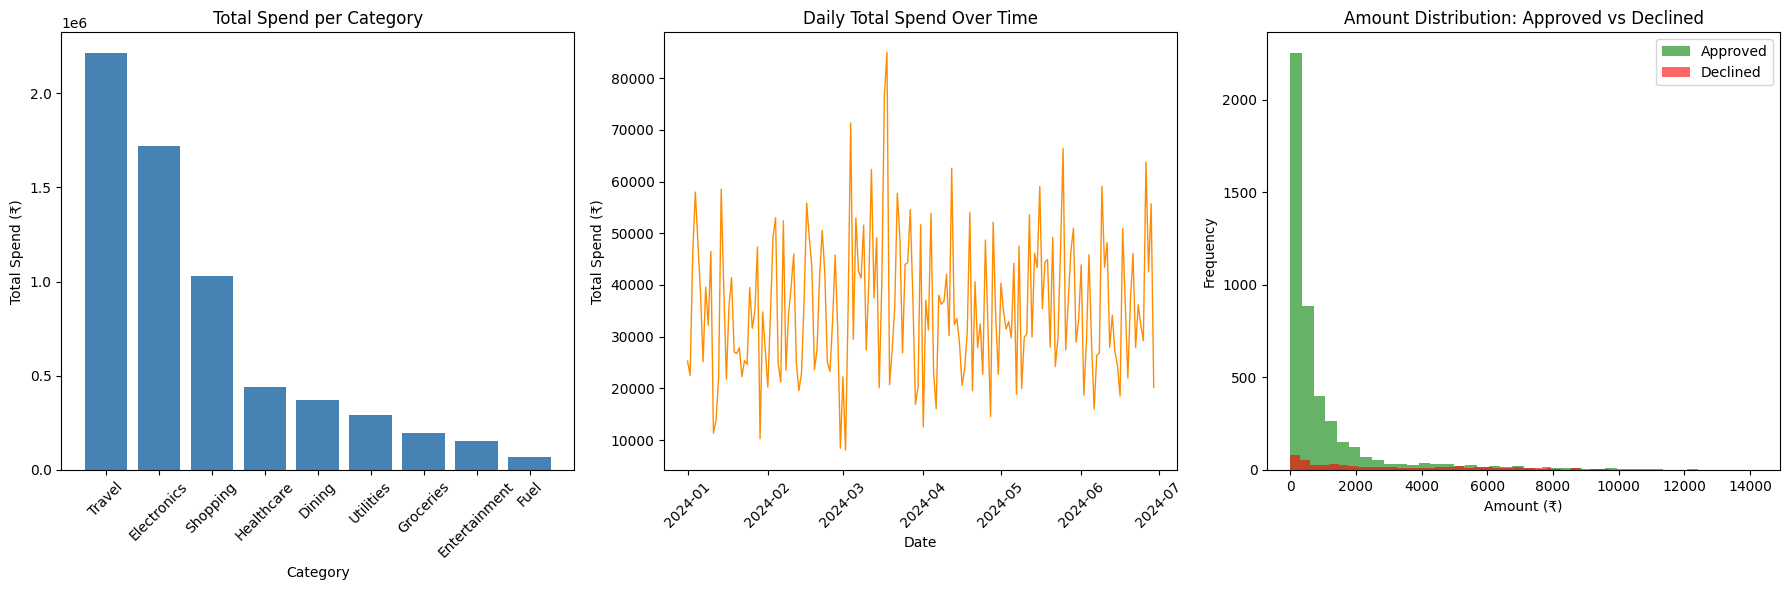

Plot saved.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cat_spend = df.groupby('category')['amount'].sum().sort_values(ascending=False)
axes[0].bar(cat_spend.index, cat_spend.values, color='steelblue')
axes[0].set_title('Total Spend per Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Spend (₹)')
axes[0].tick_params(axis='x', rotation=45)

df['date'] = df['datetime'].dt.date
daily_spend = df.groupby('date')['amount'].sum()
axes[1].plot(daily_spend.index, daily_spend.values, color='darkorange', linewidth=1)
axes[1].set_title('Daily Total Spend Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Spend (₹)')
axes[1].tick_params(axis='x', rotation=45)

approved_amounts = df[df['status'] == 'approved']['amount']
declined_amounts = df[df['status'] == 'declined']['amount']
axes[2].hist(approved_amounts, bins=40, alpha=0.6, label='Approved', color='green')
axes[2].hist(declined_amounts, bins=40, alpha=0.6, label='Declined', color='red')
axes[2].set_title('Amount Distribution: Approved vs Declined')
axes[2].set_xlabel('Amount (₹)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

fig.tight_layout()
plt.savefig('q6_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")